### **1. Distribuzioni di probabilità**
1. Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

2. Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

3. Stima il parametro di forma dal campione usando il metodo fit.

Extra:

Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

4. Traccia la funzione di distribuzione cumulativa (CDF).

5. Calcola la varianza.

## 1. CELLA DEI CALCOLI

#### LEGGENDA

- **np.random.gamma(shape, scale=1, size=N)** –> Genera N valori  casuali da una distribuzione Gamma

- **scipy.stats.gamma.fit(data)** –> Stima MLE dei parametri (forma, loc, scala)

- **scipy.stats.gamma.pdf(x, a, loc, scale)** –> Funzione di densità di probabilità (PDF)

- **scipy.stats.gamma.cdf(x, a, loc, scale)** –> Funzione di ripartizione cumulativa (CDF)

- **np.var(data)** –> Varianza campionaria

- **plt.hist(...density=True)** –> Istogramma normalizzato

- **plt.plot(x, pdf, 'r-')** –> Sovrapposizione della PDF teorica

- **stats.gamma.pdf(x, a, loc, scale)** –> PDF teorica

- **stats.gamma.cdf(x, a, loc, scale)** –> CDF teorica

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Generazione di 1000 valori da Gamma (shape = 1)
np.random.seed(42) # Per riproducibilità
shape_vero = 1
scala = 1
dati = np.random.gamma(shape_vero, scala, 1000)


# 2. Stima del parametro di forma del campione
shape_stimato, loc_stimato, scala_stimata = stats.gamma.fit(dati)


# 3. Calcolo della varianza
varianza = np.var(dati)


# 4. Preparazione per PDF e CDF
x = np.linspace(0, np.max(dati), 200)
pdf_teorica = stats.gamma.pdf(x, shape_vero, loc=0, scale=scala)
pdf_stimata = stats.gamma.pdf(x, shape_stimato, loc_stimato, scala_stimata)
cdf_teorica = stats.gamma.cdf(x, shape_vero, loc=0, scale=scala)


# Print finali
print(f"Parametro di forma vero: {shape_vero}")
print(f"Parametro di forma stimato dal campione: {shape_stimato:.4f}")
print(f"Varianza del campione: {varianza:.4f}")

Parametro di forma vero: 1
Parametro di forma stimato dal campione: 0.9596
Varianza del campione: 0.9448


## 2. CELLE DEI GRAFICI

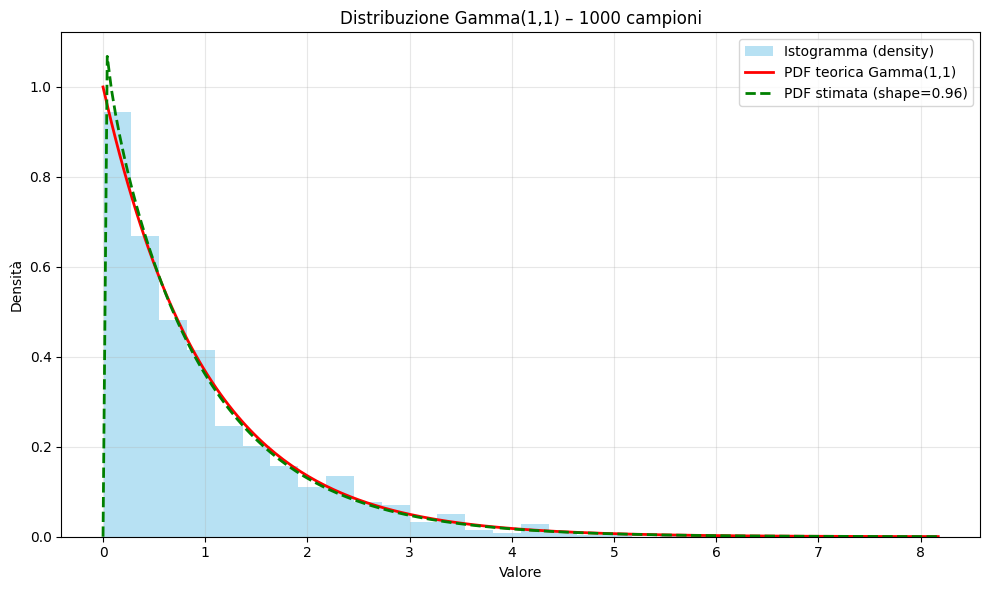

In [8]:
# Grafico 1: Istogramma + PDF (teorica e stimata)

plt.figure(figsize=(10, 6))
plt.hist(dati, bins=30, density=True, alpha=0.6, color='skyblue', label='Istogramma (density)')
plt.plot(x, pdf_teorica, 'r-', linewidth=2, label='PDF teorica Gamma(1,1)')
plt.plot(x, pdf_stimata, 'g--', linewidth=2, label=f'PDF stimata (shape={shape_stimato:.2f})')
plt.title("Distribuzione Gamma(1,1) – 1000 campioni")
plt.xlabel("Valore")
plt.ylabel("Densità")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

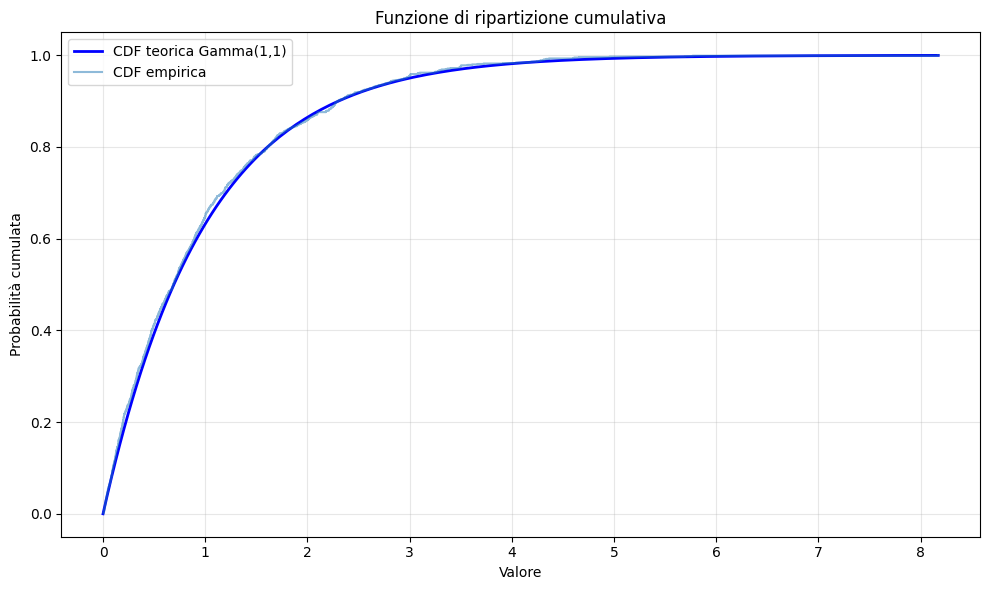

In [9]:
# Grafico 2: Funzione di distribuzione cumulativa (CDF)

plt.figure(figsize=(10, 6))
plt.plot(x, cdf_teorica, 'b-', linewidth=2, label='CDF teorica Gamma(1,1)')
plt.step(np.sort(dati), np.arange(1, len(dati)+1)/len(dati), 
         where='post', alpha=0.5, label='CDF empirica')
plt.title("Funzione di ripartizione cumulativa")
plt.xlabel("Valore")
plt.ylabel("Probabilità cumulata")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **2. Fitta i dati**
1. Prova a fittare i dati sottostanti con le migliori curve
2. Calcola il MAE e l'RMSE

## 1. CELLA DEI CALCOLI

##### LEGGENDA

- **scipy.optimize.curve_fit(funzione, x, y)** –> Stima i parametri di una funzione non lineare (es. polinomio, coseno, esponenziale) minimizzando la somma dei quadrati degli errori.

- **scipy.stats.linregress(x, y)** –> Regressione lineare semplice (pendenza, intercetta, r-squared, ecc.).

- **mean_absolute_error(y_true, y_pred)** –> Errore medio Assoluto (MAE) 

- **mean_squared_error(y_true, y_pred, squared=False)** –> Radice dell'errore quadratico medio (RSME)

- **plt.plot()** –> Grafico dei dati e delle curve fittate

- **plt.scatter()** –> Per evidenziare i punti reali

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dati
mesi = np.arange(12)
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

# Modello polinomiale di grado 3
def pol3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Fit per temp_max
popt_max, _ = curve_fit(pol3, mesi, temp_max)
# Fit per temp_min
popt_min, _ = curve_fit(pol3, mesi, temp_min)

# Predizioni sui mesi interi
pred_max = pol3(mesi, *popt_max)
pred_min = pol3(mesi, *popt_min)

# MAE e RMSE
mae_max = mean_absolute_error(temp_max, pred_max)
rmse_max = np.sqrt(mean_squared_error(temp_max, pred_max))
mae_min = mean_absolute_error(temp_min, pred_min)
rmse_min = np.sqrt(mean_squared_error(temp_min, pred_min))

# Punti per disegnare curve lisce
mesi_fitti = np.linspace(0, 11, 200)
curva_max = pol3(mesi_fitti, *popt_max)
curva_min = pol3(mesi_fitti, *popt_min)


# Printo tutto
print("Temperature massime:")
print(f"  MAE  = {mae_max:.2f} °C")
print(f"  RMSE = {rmse_max:.2f} °C\n")
print("Temperature minime:")
print(f"  MAE  = {mae_min:.2f} °C")
print(f"  RMSE = {rmse_min:.2f} °C")

Temperature massime:
  MAE  = 2.57 °C
  RMSE = 2.90 °C

Temperature minime:
  MAE  = 6.36 °C
  RMSE = 7.42 °C


## 2. CELLE DEI GRAFICI

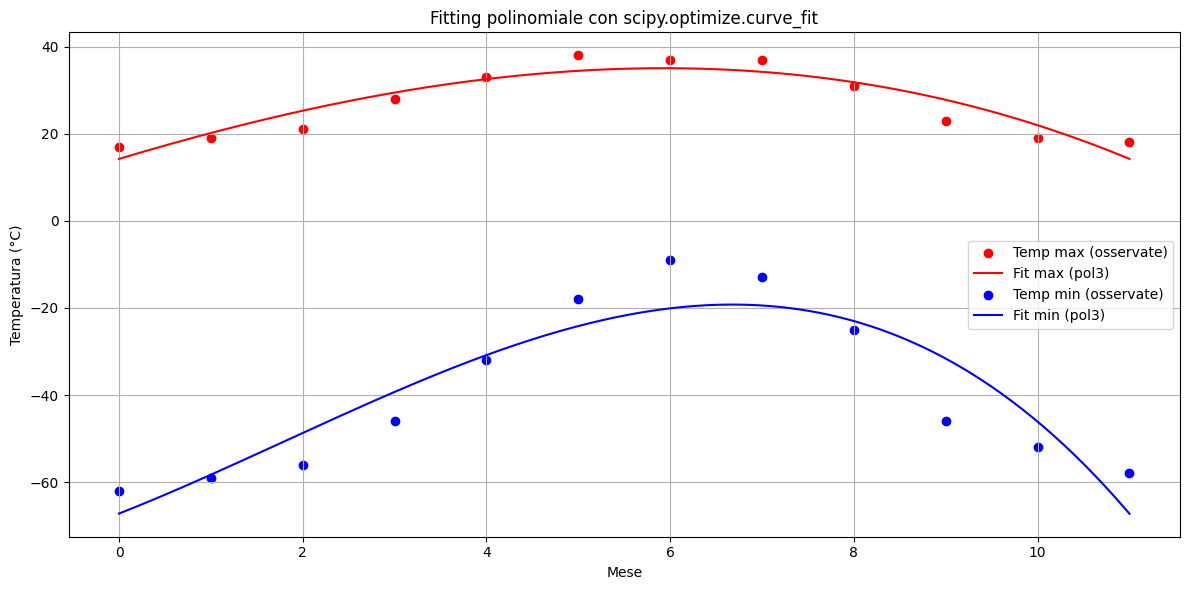

In [19]:
plt.figure(figsize=(12,6))
plt.scatter(mesi, temp_max, color='red', label='Temp max (osservate)')
plt.plot(mesi_fitti, curva_max, 'r-', label='Fit max (pol3)')
plt.scatter(mesi, temp_min, color='blue', label='Temp min (osservate)')
plt.plot(mesi_fitti, curva_min, 'b-', label='Fit min (pol3)')
plt.xlabel("Mese")
plt.ylabel("Temperatura (°C)")
plt.title("Fitting polinomiale con scipy.optimize.curve_fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

## 1. CELLA DEI CALCOLI

##### LEGGENDA

- **pd.read_csv(url)** –> Carica il dataset mtcars da URL

- **scipy.stats.linregress(x, y)** – Calcola pendenza, intercetta, coefficiente di correlazione, p-value, errore standard per una regressione lineare semplice.

- **x = df['wt']** -> Variabile indipendente (***peso***)   

- **y = df["mpg"]** –> Variabile dipendente (***consumo***)


- rvalue**2 – Coefficiente di determinazione R² (bontà del modello).

- **plt.scatter()** – Grafico a dispersione dei dati reali.

- **plt.plot()** – Retta di regressione.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Caricamento dataset
url = 'https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv'
df = pd.read_csv(url)

# Variabili
x = df['wt']      # peso (indipendente)
y = df['mpg']     # consumo (dipendente)

# Regressione lineare
reg = linregress(x, y)

pendenza = reg.slope
intercetta = reg.intercept
r2 = reg.rvalue ** 2

# Predizioni
y_pred = pendenza * x + intercetta

# Print Finali
print(f"Coefficiente angolare (slope): {pendenza:.4f}")
print(f"Intercetta: {intercetta:.4f}")
print(f"R² (coefficiente di determinazione): {r2:.4f}")

Coefficiente angolare (slope): -5.3445
Intercetta: 37.2851
R² (coefficiente di determinazione): 0.7528


## 2. CELLA DEI GRAFICI

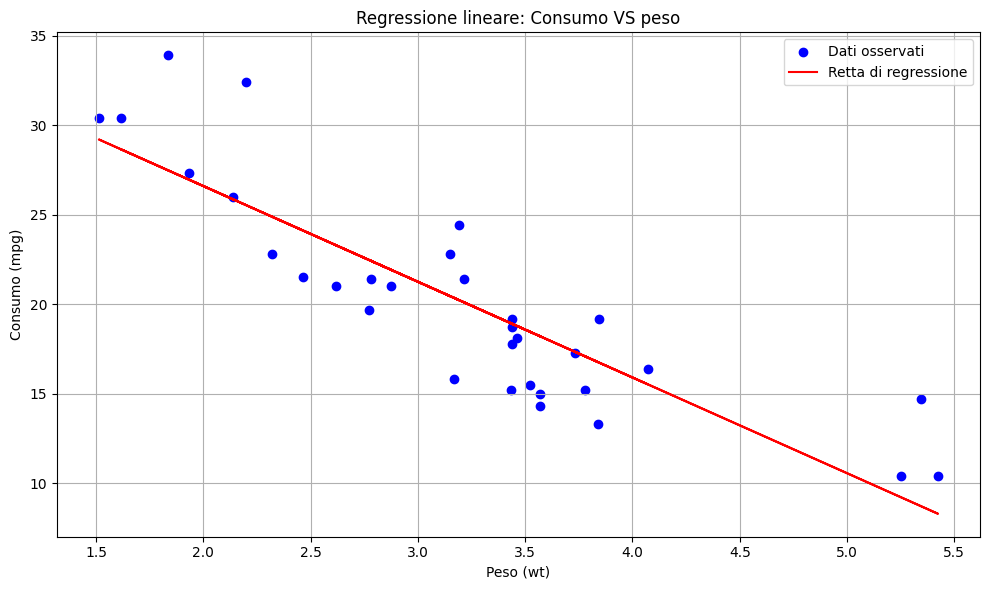

In [24]:
import matplotlib.pyplot as plt
y_pred = pendenza * x + intercetta
plt.figure(figsize=(10,6))
plt.scatter(x, y, color='blue', label='Dati osservati')
plt.plot(x, y_pred, color='red', label='Retta di regressione')
plt.xlabel("Peso (wt)")
plt.ylabel("Consumo (mpg)")
plt.title("Regressione lineare: Consumo VS peso")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()